# Comparaison Complète — 4 Variantes d'Algorithme Génétique pour le Bin Packing

**4 algorithmes comparés :**
1. `AG_BASE` — AG classique (initialisation aléatoire, sélection standard)
2. `AG_XGB` — AG + ML Initialisation (XGBoost guide la population initiale)
3. `AG_FS` — AG + ML Sélection (Fitness Sharing pénalise les doublons)
4. `AG_XGB_FS` — AG + XGBoost Initialisation **+** Fitness Sharing (combinaison complète)

**Structure du notebook :**
- **Section 0** : Configuration globale
- **Section 1** : Imports
- **Section 2** : Structures & fonctions BPP
- **Section 3** : Chargement des instances
- **Section 4** : Algorithmes (AG base, Initialisation XGB, Fitness Sharing, Hybride)
- **Section 5** : Exécution principale (6 instances × N_RUNS)
- **Section 6** : Tableau de résultats
- **Section 7** : Graphiques
- **Section 8** : Conclusion automatique
- **Section 9** : Évaluation rigoureuse *(indépendante — 20 runs × 3 instances × test de Wilcoxon)*



## 0. Configuration globale

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CONFIGURATION — modifier ici pour changer le comportement global
# ══════════════════════════════════════════════════════════════════════

N_RUNS      = 5          # Nombre de runs par instance (section 5)
MAX_GENS    = 300        # Générations max par run
POP_SIZE    = 60         # Taille de la population
NO_IMPROVE  = 80         # Arrêt par stagnation
SEED        = 42         # Graine aléatoire de base

# Paramètres initialisation XGBoost
N_ML_INDIVIDUALS = 20    # Individus générés par XGBoost dans la population initiale
NOISE_LEVEL      = 0.05  # Bruit pour diversifier les ordres ML

# Paramètres Fitness Sharing
SHARING_FREQ  = 5        # Recalcul pénalités toutes les N générations (cache)
SHARING_ALPHA = 0.4      # Intensité de la pénalisation de similarité
SHARING_MIN_GEN = 8      # Génération minimale avant l'entraînement du modèle

# Répertoire des modèles ML
MODELS_DIR = "models"

# Instances pour la section 5 (6 instances représentatives)
INSTANCE_FILES = [
    ("data/scholl/N3C1W1_A.txt",              "scholl"),
    ("data/scholl/N3C1W1_B.txt",              "scholl"),
    ("data/scholl/N3C2W2_A.txt",              "scholl"),
    ("data/falkenauer/Falkenauer_t60_00.txt",  "falkenauer"),
    ("data/falkenauer/Falkenauer_t120_00.txt", "falkenauer"),
    ("data/falkenauer/Falkenauer_t249_00.txt", "falkenauer"),
]

print(f"Config OK : {N_RUNS} runs × {len(INSTANCE_FILES)} instances × {MAX_GENS} gens max")
print(f"           XGBoost : {N_ML_INDIVIDUALS} individus ML | Fitness Sharing : alpha={SHARING_ALPHA}, freq={SHARING_FREQ}")


Config OK : 5 runs × 6 instances × 300 gens max
           XGBoost : 20 individus ML | Fitness Sharing : alpha=0.4, freq=5


## 1. Imports

In [ ]:
import os, random, time, math, json, warnings
from dataclasses import dataclass, field
from typing import List, Optional, Dict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib

from sklearn.linear_model import SGDClassifier
from scipy.stats import wilcoxon

warnings.filterwarnings('ignore')
print("Imports OK")


Imports OK


## 2. Structures & fonctions BPP

In [ ]:
# ── Structures de données ─────────────────────────────────────────────
@dataclass
class BPPInstance:
    name: str; capacity: int; items: List[int]
    optimal: Optional[int] = None; dataset_type: str = "unknown"
    @property
    def n(self): return len(self.items)

@dataclass
class GAConfig:
    pop_size: int           = 60
    crossover_prob: float   = 0.6886557798696972
    mutation_swap_rate: float     = 0.013825190220353476
    mutation_relocate_rate: float = 0.08449219051480669
    empty_bin_prob: float   = 0.157167738930715
    elitism: int = 2;  tournament_k: int = 4
    max_generations: int = 300;  no_improve_limit: int = 80

@dataclass
class GAResult:
    best_num_bins: int;  lower_bound: int
    generations_run: int;  time_seconds: float
    convergence: List[int]
    algo: str = ""  # étiquette de l'algo

print("Structures OK")


Structures OK


In [ ]:
# ── Fonctions core BPP ────────────────────────────────────────────────
def lower_bound(inst): return math.ceil(sum(inst.items) / inst.capacity)

def fitness(chrom, items, capacity):
    bl = {}
    for i, b in enumerate(chrom): bl[b] = bl.get(b, 0) + items[i]
    return len(bl), sum((capacity - l) ** 2 for l in bl.values())

def compact(chrom):
    m, r, c = {}, [], 0
    for b in chrom:
        if b not in m: m[b] = c; c += 1
        r.append(m[b])
    return r

def decode_bins(chrom, n):
    bins = {}
    for i in range(n): bins.setdefault(chrom[i], []).append(i)
    return bins

def bins_to_chromosome(bins_list, n):
    chrom = [0] * n
    for b_id, bi in enumerate(bins_list):
        for idx in bi: chrom[idx] = b_id
    return chrom

def random_packing(items, capacity):
    order = list(range(len(items))); random.shuffle(order)
    bins, rem = [], []
    for idx in order:
        w = items[idx]; pos = [b for b in range(len(bins)) if rem[b] >= w]
        if pos: b = random.choice(pos); bins[b].append(idx); rem[b] -= w
        else: bins.append([idx]); rem.append(capacity - w)
    return bins

def create_individual(inst):
    bins = random_packing(inst.items, inst.capacity)
    return bins_to_chromosome(bins, inst.n)

def tournament(pop, fits, k):
    cands = random.sample(range(len(pop)), min(k, len(pop)))
    return pop[min(cands, key=lambda i: (fits[i][0], fits[i][1]))]

print("Fonctions core OK")


Fonctions core OK


In [ ]:
# ── Opérateurs génétiques ────────────────────────────────────────────
def crossover(p1, p2, items, capacity):
    n = len(p1); bins1 = decode_bins(p1, n); bins2 = decode_bins(p2, n)
    all_bins = list(bins1.values()) + list(bins2.values()); random.shuffle(all_bins)
    child = [-1] * n; assigned = set(); nid = 0
    for grp in all_bins:
        free = [i for i in grp if i not in assigned]
        if not free: continue
        if sum(items[i] for i in free) <= capacity:
            for i in free: child[i] = nid; assigned.add(i)
            nid += 1
    unplaced = [i for i in range(n) if i not in assigned]; random.shuffle(unplaced)
    brem = {}
    for i in range(n):
        b = child[i]
        if b >= 0: brem[b] = brem.get(b, capacity) - items[i]
    for i in unplaced:
        pos = [b for b in brem if brem[b] >= items[i]]
        if pos: b = random.choice(pos); child[i] = b; brem[b] -= items[i]
        else: child[i] = nid; brem[nid] = capacity - items[i]; nid += 1
    return compact(child)

def mutate_swap(chrom, items, capacity, rate=0.05):
    chrom = chrom[:]; n = len(chrom)
    for i in range(n):
        if random.random() < rate:
            j = random.randrange(n)
            if chrom[i] == chrom[j]: continue
            bi, bj = chrom[i], chrom[j]; loads = {}
            for k in range(n): loads[chrom[k]] = loads.get(chrom[k], 0) + items[k]
            if loads[bi] - items[i] + items[j] <= capacity and loads[bj] - items[j] + items[i] <= capacity:
                chrom[i] = bj; chrom[j] = bi
    return compact(chrom)

def mutate_relocate(chrom, items, capacity, rate=0.05):
    chrom = chrom[:]; n = len(chrom); nb = max(chrom) + 1
    for i in range(n):
        if random.random() < rate:
            loads = {}
            for k in range(n): loads[chrom[k]] = loads.get(chrom[k], 0) + items[k]
            cands = [b for b in range(nb) if b != chrom[i] and loads.get(b, 0) + items[i] <= capacity]
            if cands: chrom[i] = random.choice(cands)
    return compact(chrom)

def mutate_empty_bin(chrom, items, capacity):
    chrom = chrom[:]; n = len(chrom); bins = decode_bins(chrom, n)
    bl = {b: sum(items[i] for i in idxs) for b, idxs in bins.items()}
    target = min(bl, key=bl.get); ti = bins[target][:]; random.shuffle(ti); nc = chrom[:]
    for item_idx in ti:
        placed = False; cl = {}
        for k in range(n):
            if nc[k] != target: cl[nc[k]] = cl.get(nc[k], 0) + items[k]
        for b in sorted(cl, key=lambda x: cl[x], reverse=True):
            if cl.get(b, 0) + items[item_idx] <= capacity:
                nc[item_idx] = b; placed = True; break
        if not placed: return chrom
    return compact(nc)

print("Opérateurs génétiques OK")


Opérateurs génétiques OK


In [ ]:
# ── Fonctions d'initialisation ───────────────────────────────────────
def init_population_random(inst, pop_size, **kwargs):
    """Initialisation aléatoire classique."""
    return [create_individual(inst) for _ in range(pop_size)]


def order_to_chromosome(order, inst):
    items = inst.items; capacity = inst.capacity
    bins, remaining = [], []
    for idx in order:
        w = items[idx]; placed = False
        for b in range(len(bins)):
            if remaining[b] >= w:
                bins[b].append(idx); remaining[b] -= w; placed = True; break
        if not placed:
            bins.append([idx]); remaining.append(capacity - w)
    return bins_to_chromosome(bins, len(items))


def generate_individuals_from_model(inst, model, n_individuals, noise_level=0.05):
    features = _extract_features_for_instance(inst)
    base_scores = model.predict(features)
    individuals = []
    for _ in range(n_individuals):
        noisy = base_scores + np.random.normal(0, noise_level, len(base_scores))
        individuals.append(order_to_chromosome(np.argsort(noisy).tolist(), inst))
    return individuals


def init_population_xgb(inst, pop_size, model=None, n_ml_individuals=20, noise_level=0.05, **kwargs):
    """Initialisation hybride : 1 FFD + n_ml_individuals XGBoost + complétion aléatoire."""
    pop = []
    # 1. FFD
    ffd_order = sorted(range(inst.n), key=lambda i: inst.items[i], reverse=True)
    pop.append(order_to_chromosome(ffd_order, inst))
    # 2. XGBoost
    if model is not None:
        pop.extend(generate_individuals_from_model(inst, model, n_ml_individuals, noise_level))
    # 3. Aléatoire
    while len(pop) < pop_size:
        pop.append(create_individual(inst))
    return pop


def _extract_features_for_instance(inst):
    items = inst.items; n = len(items); capacity = inst.capacity
    mean_size = np.mean(items); std_size = np.std(items)
    max_size = max(items); min_size = min(items)
    total = sum(items); fill_ratio = total / capacity
    n_large  = sum(1 for x in items if x > 0.5 * capacity)
    n_medium = sum(1 for x in items if 0.25 * capacity < x <= 0.5 * capacity)
    n_small  = sum(1 for x in items if x <= 0.25 * capacity)
    FEATURE_COLS = [
        'item_size','item_size_norm','ratio_to_mean','ratio_to_max','ratio_to_min',
        'diff_to_mean','is_large','is_medium','is_small',
        'inst_mean','inst_std','inst_max','inst_min','inst_fill_ratio',
        'inst_n_large','inst_n_medium','inst_n_small','inst_n_items'
    ]
    features = []
    for item in items:
        row = [
            item, item / capacity, item / (mean_size + 1e-9), item / (max_size + 1e-9), item / (min_size + 1e-9),
            item - mean_size,
            1 if item > 0.5 * capacity else 0,
            1 if 0.25 * capacity < item <= 0.5 * capacity else 0,
            1 if item <= 0.25 * capacity else 0,
            mean_size, std_size, max_size, min_size, fill_ratio,
            n_large, n_medium, n_small, n
        ]
        features.append(row)
    return np.array(features)

print("Initialisations OK")


Initialisations OK


## 3. Chargement des instances

In [ ]:
def load_scholl(path):
    with open(path) as f: lines = [l.strip() for l in f if l.strip()]
    n = int(lines[0]); capacity = int(lines[1])
    items = [int(lines[2 + i]) for i in range(n)]
    return BPPInstance(name=Path(path).stem, capacity=capacity, items=items, dataset_type="scholl")

def load_falkenauer(path):
    with open(path) as f: lines = [l.strip() for l in f if l.strip()]
    idx = 0
    if not lines[idx].lstrip("-").isdigit(): idx += 1
    n = int(lines[idx]); idx += 1
    capacity = int(lines[idx]); idx += 1
    items = [int(lines[idx + i]) for i in range(n)]; idx += n
    optimal = None
    if idx < len(lines):
        try: optimal = int(lines[idx])
        except: pass
    return BPPInstance(name=Path(path).stem, capacity=capacity, items=items,
                       optimal=optimal, dataset_type="falkenauer")

instances = []
for path, dtype in INSTANCE_FILES:
    if not os.path.exists(path):
        print(f"  ⚠️  MANQUANT : {path}"); continue
    try:
        inst = load_scholl(path) if dtype == "scholl" else load_falkenauer(path)
        instances.append(inst)
        lb = lower_bound(inst)
        opt = f"  (optimal={inst.optimal})" if inst.optimal else ""
        print(f"  ✓  {inst.name:<35} n={inst.n:>5}  C={inst.capacity:>4}  LB={lb:>4}{opt}")
    except Exception as e:
        print(f"  ✗  ERREUR {path}: {e}")

assert instances, "Aucune instance chargée — vérifier INSTANCE_FILES"
print(f"\n{len(instances)} instance(s) chargée(s) — prêt.")


  ✓  N3C1W1_A                            n=  200  C= 100  LB= 101
  ✓  N3C1W1_B                            n=  200  C= 100  LB= 109
  ✓  N3C2W2_A                            n=  200  C= 120  LB= 103
  ✓  Falkenauer_t60_00                   n=   60  C=1000  LB=  20
  ✓  Falkenauer_t120_00                  n=  120  C=1000  LB=  40
  ✓  Falkenauer_t249_00                  n=  249  C=1000  LB=  83

6 instance(s) chargée(s) — prêt.


## 4. Algorithmes

### 4.1 Chargement du modèle XGBoost
> Le modèle est chargé une seule fois ici et utilisé par `AG_XGB` et `AG_XGB_FS`.

In [ ]:
import os, json, joblib

xgb_model = None
if os.path.exists(MODELS_DIR):
    xgb_path = os.path.join(MODELS_DIR, "model_xgb.joblib")
    if os.path.exists(xgb_path):
        xgb_model = joblib.load(xgb_path)
        print(f"✓ Modèle XGBoost chargé depuis {xgb_path}")
    else:
        print(f"model_xgb.joblib introuvable dans {MODELS_DIR}")
else:
    print(f"Dossier models/ introuvable — les variantes XGB utiliseront FFD + aléatoire")

if xgb_model is None:
    print("   → AG_XGB et AG_XGB_FS fonctionneront sans le modèle XGBoost (FFD + random seulement)")


✓ Modèle XGBoost chargé depuis models/model_xgb.joblib


### 4.2 Boucle AG générique

In [ ]:
def run_ga_generic(inst, cfg, init_func, init_kwargs=None,
                   use_fitness_sharing=False, algo_label=""):
    """
    Boucle GA unique utilisée par les 4 variantes.
    - init_func      : fonction d'initialisation de la population
    - init_kwargs    : arguments supplémentaires pour init_func
    - use_fitness_sharing : active le ML Fitness Sharing pendant la sélection
    """
    items = inst.items; cap = inst.capacity; lb = lower_bound(inst)
    if init_kwargs is None: init_kwargs = {}

    pop = init_func(inst, pop_size=cfg.pop_size, **init_kwargs)
    fits = [fitness(c, items, cap) for c in pop]

    bi = min(range(len(pop)), key=lambda i: (fits[i][0], fits[i][1]))
    bfit = fits[bi]; conv = [bfit[0]]; noim = 0
    t0 = time.perf_counter(); gen = 0

    # ── Fitness Sharing (si activé) ──────────────────────────────────
    if use_fitness_sharing:
        sharing = MLFitnessSharing(alpha=SHARING_ALPHA, min_gen=SHARING_MIN_GEN)
        cached_penalties = np.zeros(cfg.pop_size)

    for gen in range(1, cfg.max_generations + 1):

        # Calcul des fitness ajustées (Fitness Sharing)
        if use_fitness_sharing:
            if gen % SHARING_FREQ == 0 or gen == 1:
                feats_mat = sharing.extract_features_batch(pop, items, cap)
                if gen >= sharing.min_gen and gen % (SHARING_FREQ * 3) == 0:
                    sharing.train(feats_mat, fits)
                cached_penalties = sharing.compute_penalties(feats_mat)
            adjusted = sharing.adjust_fitness(fits, cached_penalties)
            sel_fits = [(float(adjusted[i]), fits[i][1]) for i in range(len(fits))]
        else:
            sel_fits = fits

        # Elitisme (sur fitness réelle, pas ajustée)
        sidx = sorted(range(len(pop)), key=lambda i: (fits[i][0], fits[i][1]))
        np2 = [pop[i][:] for i in sidx[:cfg.elitism]]

        # Reproduction
        while len(np2) < cfg.pop_size:
            p1 = tournament(pop, sel_fits, cfg.tournament_k)
            p2 = tournament(pop, sel_fits, cfg.tournament_k)
            ch = crossover(p1, p2, items, cap) if random.random() < cfg.crossover_prob \
                 else (p1[:] if random.random() < 0.5 else p2[:])
            ch = mutate_swap(ch, items, cap, cfg.mutation_swap_rate)
            ch = mutate_relocate(ch, items, cap, cfg.mutation_relocate_rate)
            if random.random() < cfg.empty_bin_prob: ch = mutate_empty_bin(ch, items, cap)
            np2.append(ch)

        pop = np2; fits = [fitness(c, items, cap) for c in pop]
        cbi = min(range(len(pop)), key=lambda i: (fits[i][0], fits[i][1])); cbf = fits[cbi]

        if cbf[0] < bfit[0] or (cbf[0] == bfit[0] and cbf[1] < bfit[1]):
            bfit = cbf; noim = 0
        else:
            noim += 1
        conv.append(bfit[0])
        if bfit[0] == lb or noim >= cfg.no_improve_limit: break

    return GAResult(
        best_num_bins=bfit[0], lower_bound=lb,
        generations_run=gen, time_seconds=time.perf_counter() - t0,
        convergence=conv, algo=algo_label
    )

print("Boucle GA générique OK")


Boucle GA générique OK


### 4.3 Classe MLFitnessSharing

In [ ]:
class MLFitnessSharing:
    """
    Fitness Sharing basé sur un SGDClassifier en ligne.
    3 optimisations de performance :
      1. extract_features O(n) — lecture directe du chromosome
      2. compute_penalties vectorisé numpy
      3. Cache des pénalités toutes les SHARING_FREQ générations
    """
    def __init__(self, alpha=0.4, min_gen=8):
        self.alpha = alpha; self.min_gen = min_gen
        self.model = SGDClassifier(loss='log_loss', warm_start=True, max_iter=1)
        self.trained = False

    def extract_features_batch(self, pop, items, cap):
        feats = []
        for chrom in pop:
            loads = {}
            for i, b in enumerate(chrom): loads[b] = loads.get(b, 0) + items[i]
            fills = np.array(list(loads.values()), dtype=float) / cap
            feats.append([
                fills.mean(), fills.std(),
                float((fills > 0.9).sum()), float((fills < 0.5).sum()),
                float(len(fills)), fills.min(), fills.max()
            ])
        return np.array(feats, dtype=float)

    def train(self, feats_mat, fits):
        X, y = [], []
        n = len(feats_mat)
        for i in range(0, n - 1, 2):
            diff = np.abs(feats_mat[i] - feats_mat[i + 1])
            same = 1 if fits[i][0] == fits[i + 1][0] else 0
            X.append(diff); y.append(same)
        if len(set(y)) < 2: return
        self.model.partial_fit(X, y, classes=[0, 1])
        self.trained = True

    def compute_penalties(self, feats_mat):
        if not self.trained: return np.zeros(len(feats_mat))
        norms = np.linalg.norm(feats_mat, axis=1, keepdims=True)
        norm_sum = norms + norms.T + 1e-9
        diff_sum = np.abs(feats_mat[:, None, :] - feats_mat[None, :, :]).sum(axis=2)
        sim_mat = np.clip(1.0 - diff_sum / norm_sum, 0, None)
        np.fill_diagonal(sim_mat, 0)
        return sim_mat.mean(axis=1)

    def adjust_fitness(self, fits, penalties):
        bins = np.array([f[0] for f in fits], dtype=float)
        return bins * (1.0 + self.alpha * penalties)

print("MLFitnessSharing OK")


MLFitnessSharing OK


### 4.4 Wrappers des 4 variantes

In [ ]:
def run_ag_base(inst, cfg):
    """AG classique — initialisation aléatoire, sélection standard."""
    return run_ga_generic(inst, cfg,
        init_func=init_population_random,
        use_fitness_sharing=False,
        algo_label="AG_BASE")


def run_ag_xgb(inst, cfg, model=None):
    """AG + Initialisation XGBoost — meilleur départ, sélection standard."""
    return run_ga_generic(inst, cfg,
        init_func=init_population_xgb,
        init_kwargs=dict(model=model, n_ml_individuals=N_ML_INDIVIDUALS, noise_level=NOISE_LEVEL),
        use_fitness_sharing=False,
        algo_label="AG_XGB")


def run_ag_fs(inst, cfg):
    """AG + ML Fitness Sharing — initialisation aléatoire, sélection diversifiée."""
    return run_ga_generic(inst, cfg,
        init_func=init_population_random,
        use_fitness_sharing=True,
        algo_label="AG_FS")


def run_ag_xgb_fs(inst, cfg, model=None):
    """AG + XGBoost + Fitness Sharing — combinaison complète."""
    return run_ga_generic(inst, cfg,
        init_func=init_population_xgb,
        init_kwargs=dict(model=model, n_ml_individuals=N_ML_INDIVIDUALS, noise_level=NOISE_LEVEL),
        use_fitness_sharing=True,
        algo_label="AG_XGB_FS")


ALGOS = [
    ("AG_BASE",   lambda inst, cfg: run_ag_base(inst, cfg)),
    ("AG_XGB",    lambda inst, cfg: run_ag_xgb(inst, cfg, model=xgb_model)),
    ("AG_FS",     lambda inst, cfg: run_ag_fs(inst, cfg)),
    ("AG_XGB_FS", lambda inst, cfg: run_ag_xgb_fs(inst, cfg, model=xgb_model)),
]

ALGO_LABELS  = [a[0] for a in ALGOS]
ALGO_COLORS  = ["#4A90D9", "#E8A838", "#4CAF50", "#9B59B6"]
ALGO_MARKERS = ["o", "s", "^", "D"]

print("4 variantes prêtes :", ALGO_LABELS)


4 variantes prêtes : ['AG_BASE', 'AG_XGB', 'AG_FS', 'AG_XGB_FS']


## 5. Exécution principale

In [ ]:
assert instances, "Charger les instances (Section 3) avant d'exécuter"

cfg = GAConfig(pop_size=POP_SIZE, max_generations=MAX_GENS, no_improve_limit=NO_IMPROVE)

# Structure : results[inst_name][algo_label] = [GAResult, ...]
results = {inst.name: {label: [] for label, _ in ALGOS} for inst in instances}

t_start = time.perf_counter()

for inst in instances:
    lb = lower_bound(inst)
    print(f"\n[{inst.name}]  n={inst.n}  LB={lb}  opt={inst.optimal}")
    print(f"  {'Run':<5}", end="")
    for label, _ in ALGOS: print(f"  {label:>10}", end="")
    print()

    for run in range(N_RUNS):
        seed = SEED + run
        row_str = f"  {run+1:<5}"
        for label, fn in ALGOS:
            random.seed(seed); np.random.seed(seed)
            r = fn(inst, cfg)
            results[inst.name][label].append(r)
            row_str += f"  {r.best_num_bins:>10}"
        print(row_str)

    # Résumé rapide
    means = {label: np.mean([r.best_num_bins for r in results[inst.name][label]]) for label, _ in ALGOS}
    best_algo = min(means, key=means.get)
    print(f"  Moyennes : " + "  ".join(f"{l}={means[l]:.2f}" for l, _ in ALGOS))
    print(f"  ★ Meilleur : {best_algo} ({means[best_algo]:.2f} bins)")

print(f"\n{'='*60}")
print(f"Temps total exécution : {time.perf_counter()-t_start:.1f}s")



[N3C1W1_A]  n=200  LB=101  opt=None
  Run       AG_BASE      AG_XGB       AG_FS   AG_XGB_FS
  1             110         106         109         106
  2             110         106         109         106
  3             108         106         108         106
  4             110         106         109         106
  5             110         106         109         106
  Moyennes : AG_BASE=109.60  AG_XGB=106.00  AG_FS=108.80  AG_XGB_FS=106.00
  ★ Meilleur : AG_XGB (106.00 bins)

[N3C1W1_B]  n=200  LB=109  opt=None
  Run       AG_BASE      AG_XGB       AG_FS   AG_XGB_FS
  1             118         114         117         114
  2             117         114         117         114
  3             118         114         117         114
  4             119         114         117         114
  5             117         114         117         114
  Moyennes : AG_BASE=117.80  AG_XGB=114.00  AG_FS=117.00  AG_XGB_FS=114.00
  ★ Meilleur : AG_XGB (114.00 bins)

[N3C2W2_A]  n=200  LB=103  opt=

## 6. Tableau de résultats

In [ ]:
def compute_metrics(run_list, lb):
    bins = [r.best_num_bins for r in run_list]
    best = min(bins); mean = np.mean(bins); std = np.std(bins)
    gap = (mean - lb) / lb * 100 if lb > 0 else 0
    sr = sum(1 for b in bins if b == best) / len(bins) * 100
    gens = np.mean([r.generations_run for r in run_list])
    t = np.mean([r.time_seconds for r in run_list])
    return dict(best=best, mean=round(mean, 2), std=round(std, 3),
                gap=round(gap, 2), sr=round(sr, 1), gens=round(gens, 1), t=round(t, 2))


rows = []
for inst in instances:
    lb = lower_bound(inst)
    for label, _ in ALGOS:
        m = compute_metrics(results[inst.name][label], lb)
        rows.append({
            "Instance": inst.name, "n": inst.n, "LB": lb,
            "Algo": label,
            "Best": m["best"], "Mean": m["mean"], "Std": m["std"],
            "Gap%": m["gap"], "SR%": m["sr"],
            "Gens": m["gens"], "Temps_s": m["t"]
        })

df = pd.DataFrame(rows)

# Tableau pivot lisible
print("=" * 110)
print(f"{'Instance':<22} {'n':>5} {'LB':>4} | ", end="")
for label, _ in ALGOS: print(f" {label:>10}(mean)", end="")
print(" | Meilleur")
print("-" * 110)

for inst in instances:
    lb = lower_bound(inst)
    sub = df[(df.Instance == inst.name)]
    means = {row.Algo: row.Mean for _, row in sub.iterrows()}
    best_algo = min(means, key=means.get)
    print(f"{inst.name:<22} {inst.n:>5} {lb:>4} | ", end="")
    for label, _ in ALGOS:
        v = means.get(label, float('nan'))
        marker = " ★" if label == best_algo else "  "
        print(f" {v:>10.2f}{marker}", end="")
    print(f" | {best_algo}")

print("=" * 110)
print("\nStatistiques globales par algorithme :")
summary = df.groupby("Algo")[["Mean", "Gap%", "Gens", "Temps_s"]].mean().round(2)
summary.index = pd.CategoricalIndex(summary.index, categories=ALGO_LABELS, ordered=True)
print(summary.sort_index().to_string())


Instance                   n   LB |     AG_BASE(mean)     AG_XGB(mean)      AG_FS(mean)  AG_XGB_FS(mean) | Meilleur
--------------------------------------------------------------------------------------------------------------
N3C1W1_A                 200  101 |      109.60       106.00 ★     108.80       106.00   | AG_XGB
N3C1W1_B                 200  109 |      117.80       114.00 ★     117.00       114.00   | AG_XGB
N3C2W2_A                 200  103 |      112.80       107.00 ★     111.40       107.00   | AG_XGB
Falkenauer_t60_00         60   20 |       22.00 ★      22.00        22.00        22.00   | AG_BASE
Falkenauer_t120_00       120   40 |       44.00        44.00        43.20 ★      43.40   | AG_FS
Falkenauer_t249_00       249   83 |       90.20        90.80        89.00 ★      89.80   | AG_FS

Statistiques globales par algorithme :
            Mean  Gap%    Gens  Temps_s
Algo                                   
AG_BASE    82.73  9.13  300.00    16.59
AG_XGB     80.63  7.14  29

## 7. Graphiques

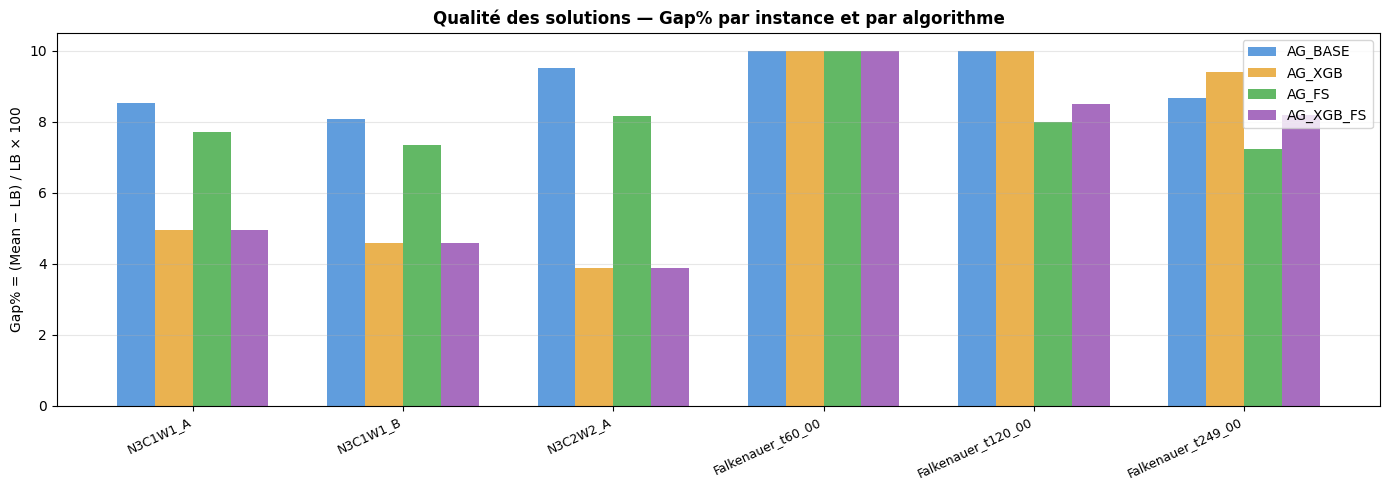

G1 sauvegardé


In [ ]:
# ── Graphique 1 : Gap% par instance et par algo ──────────────────────
inst_names = [inst.name for inst in instances]
x = np.arange(len(inst_names)); w = 0.18

fig, ax = plt.subplots(figsize=(14, 5))
for k, (label, _) in enumerate(ALGOS):
    gaps = [df[(df.Instance == inst.name) & (df.Algo == label)]["Gap%"].values[0]
            for inst in instances]
    offset = (k - 1.5) * w
    bars = ax.bar(x + offset, gaps, w, label=label,
                  color=ALGO_COLORS[k], alpha=0.88)

ax.set_xticks(x); ax.set_xticklabels(inst_names, rotation=25, ha='right', fontsize=9)
ax.set_ylabel("Gap% = (Mean − LB) / LB × 100")
ax.set_title("Qualité des solutions — Gap% par instance et par algorithme", fontweight='bold')
ax.legend(loc='upper right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('g1_gap_par_instance.png', dpi=130, bbox_inches='tight')
plt.show()
print("G1 sauvegardé")


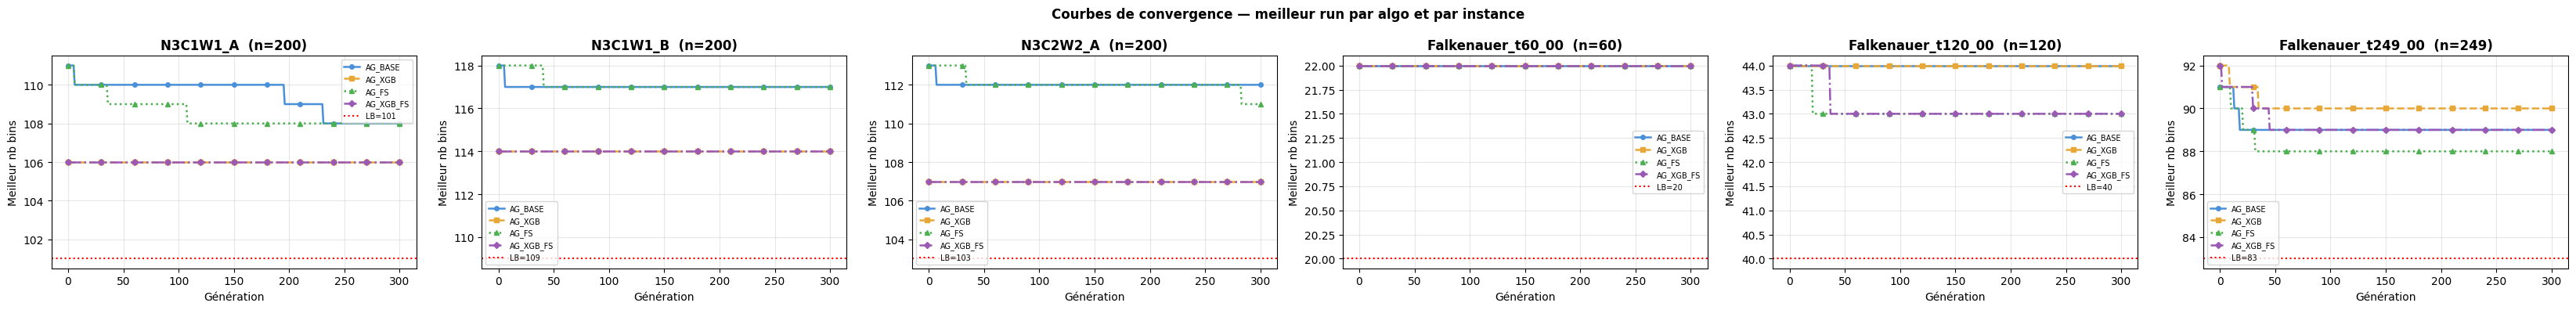

G2 sauvegardé


In [ ]:
# ── Graphique 2 : Courbes de convergence (meilleur run) ───────────────
n_inst = len(instances)
fig, axes = plt.subplots(1, n_inst, figsize=(5.5 * n_inst, 4), squeeze=False)

for idx, inst in enumerate(instances):
    ax = axes[0][idx]; lb = lower_bound(inst)
    for k, (label, _) in enumerate(ALGOS):
        best_run = min(results[inst.name][label], key=lambda r: r.best_num_bins)
        ax.plot(best_run.convergence, color=ALGO_COLORS[k], linewidth=1.8,
                linestyle=['-','--',':','-.'][k], label=label, marker=ALGO_MARKERS[k],
                markevery=max(1, len(best_run.convergence)//10), markersize=4)
    ax.axhline(lb, color='red', linestyle=':', linewidth=1.5, label=f'LB={lb}')
    if inst.optimal:
        ax.axhline(inst.optimal, color='purple', linestyle='-.', linewidth=1, label=f'Opt={inst.optimal}')
    ax.set_xlabel('Génération'); ax.set_ylabel('Meilleur nb bins')
    ax.set_title(f'{inst.name}  (n={inst.n})', fontweight='bold')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

fig.suptitle('Courbes de convergence — meilleur run par algo et par instance',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('g2_convergence.png', dpi=130, bbox_inches='tight')
plt.show()
print("G2 sauvegardé")


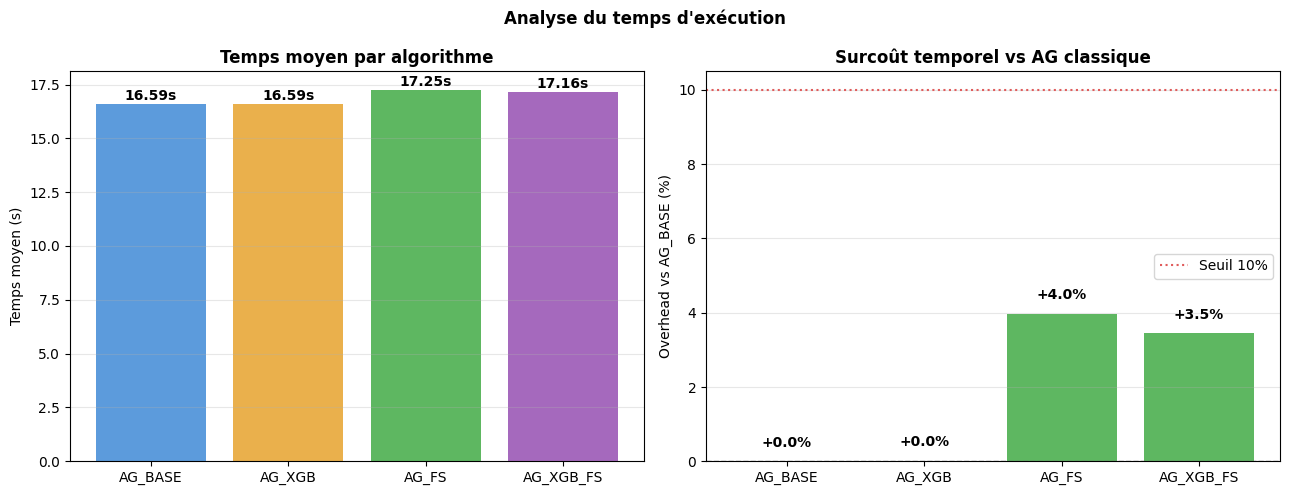

G3 sauvegardé


In [ ]:
# ── Graphique 3 : Comparaison Temps moyen par algo ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# G3a — Temps moyen global
ax = axes[0]
mean_times = [df[df.Algo == label]["Temps_s"].mean() for label, _ in ALGOS]
bars = ax.bar(ALGO_LABELS, mean_times, color=ALGO_COLORS, alpha=0.9)
for bar, val in zip(bars, mean_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}s', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Temps moyen (s)'); ax.set_title('Temps moyen par algorithme', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# G3b — Overhead vs AG_BASE
ax = axes[1]
base_time = df[df.Algo == "AG_BASE"]["Temps_s"].mean()
overheads = [(df[df.Algo == label]["Temps_s"].mean() - base_time) / base_time * 100
             for label, _ in ALGOS]
colors_oh = ['#4A90D9' if v <= 0 else ('#4CAF50' if v <= 10 else '#E05C5C') for v in overheads]
bars = ax.bar(ALGO_LABELS, overheads, color=colors_oh, alpha=0.9)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axhline(10, color='#E05C5C', linestyle=':', linewidth=1.5, label='Seuil 10%')
for bar, val in zip(bars, overheads):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.3 if val >= 0 else -1.5),
            f'{val:+.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Overhead vs AG_BASE (%)'); ax.legend()
ax.set_title('Surcoût temporel vs AG classique', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Analyse du temps d\'exécution', fontweight='bold')
plt.tight_layout()
plt.savefig('g3_temps.png', dpi=130, bbox_inches='tight')
plt.show()
print("G3 sauvegardé")


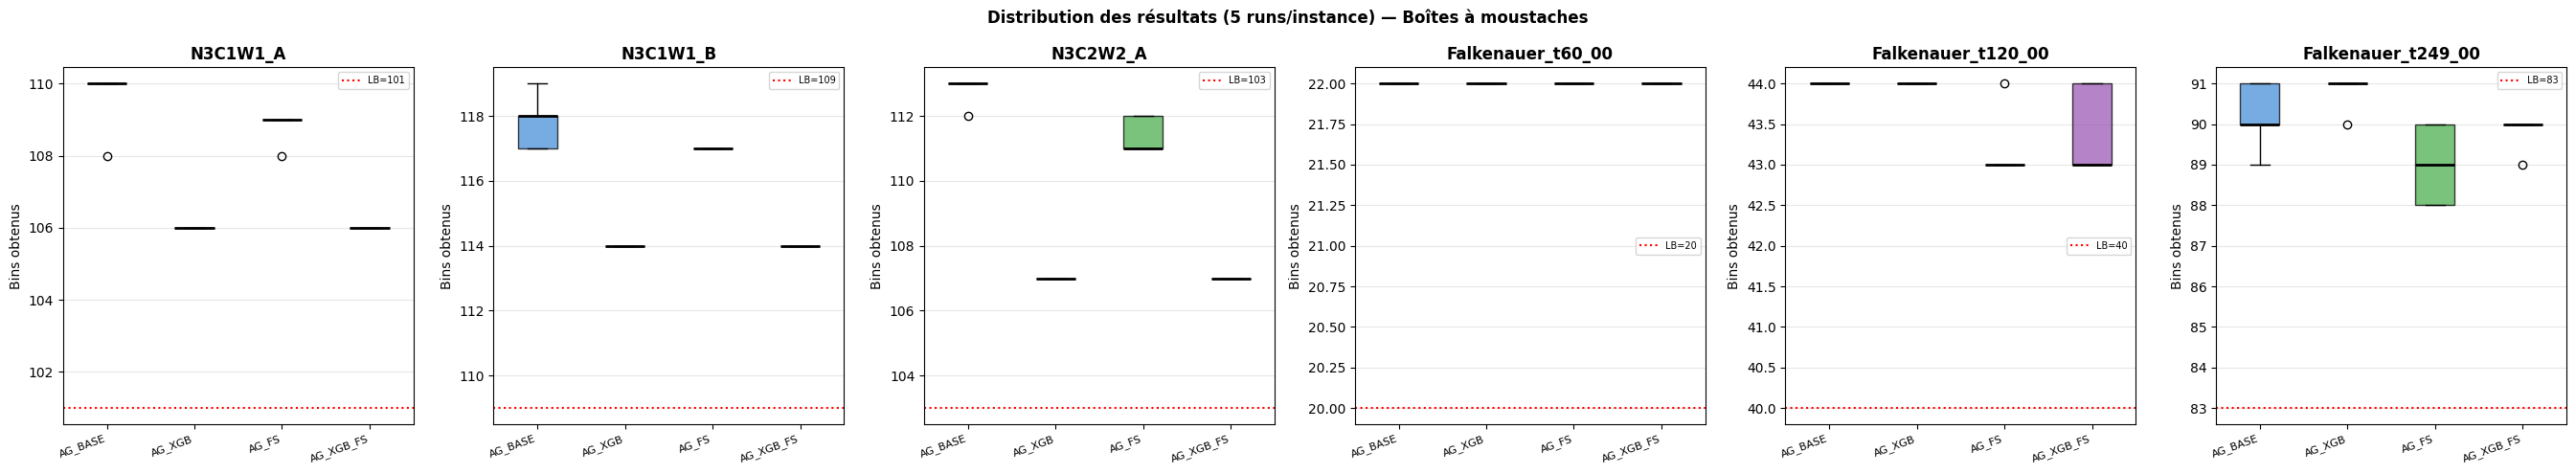

G4 sauvegardé


In [ ]:
# ── Graphique 4 : Boîte à moustaches des bins obtenus ────────────────
fig, axes = plt.subplots(1, n_inst, figsize=(4.5 * n_inst, 5), squeeze=False)

for idx, inst in enumerate(instances):
    ax = axes[0][idx]; lb = lower_bound(inst)
    data = []
    for label, _ in ALGOS:
        data.append([r.best_num_bins for r in results[inst.name][label]])
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ALGO_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.axhline(lb, color='red', linestyle=':', linewidth=1.5, label=f'LB={lb}')
    ax.set_xticks(range(1, len(ALGOS) + 1))
    ax.set_xticklabels(ALGO_LABELS, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('Bins obtenus'); ax.set_title(f'{inst.name}', fontweight='bold')
    ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'Distribution des résultats ({N_RUNS} runs/instance) — Boîtes à moustaches',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('g4_boxplots.png', dpi=130, bbox_inches='tight')
plt.show()
print("G4 sauvegardé")


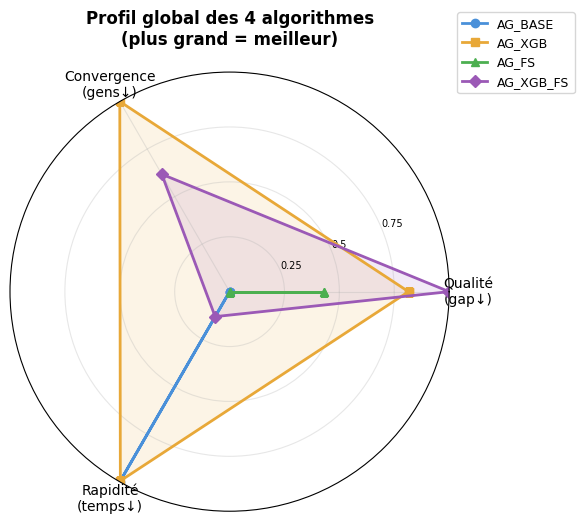

G5 sauvegardé


In [ ]:
# ── Graphique 5 : Radar — profil global de chaque algo ───────────────
# Métriques normalisées sur 3 axes : Qualité (gap↓), Vitesse (gens↓), Temps (↓)
summary_g5 = df.groupby("Algo")[["Gap%", "Gens", "Temps_s"]].mean()
summary_g5.index = pd.CategoricalIndex(summary_g5.index, categories=ALGO_LABELS, ordered=True)
summary_g5 = summary_g5.sort_index()

# Normalisation inversée (0=pire, 1=meilleur)
def norm_inv(series):
    mx, mn = series.max(), series.min()
    if mx == mn: return pd.Series([0.5] * len(series), index=series.index)
    return 1 - (series - mn) / (mx - mn)

radar_df = pd.DataFrame({
    "Qualité\n(gap↓)": norm_inv(summary_g5["Gap%"]),
    "Convergence\n(gens↓)": norm_inv(summary_g5["Gens"]),
    "Rapidité\n(temps↓)": norm_inv(summary_g5["Temps_s"]),
}, index=ALGO_LABELS)

categories = list(radar_df.columns)
N_cat = len(categories)
angles = [n / float(N_cat) * 2 * math.pi for n in range(N_cat)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for k, label in enumerate(ALGO_LABELS):
    values = radar_df.loc[label].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, color=ALGO_COLORS[k], linewidth=2, label=label,
            marker=ALGO_MARKERS[k], markersize=6)
    ax.fill(angles, values, color=ALGO_COLORS[k], alpha=0.12)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1); ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['0.25', '0.5', '0.75'], fontsize=7)
ax.set_title('Profil global des 4 algorithmes\n(plus grand = meilleur)',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('g5_radar.png', dpi=130, bbox_inches='tight')
plt.show()
print("G5 sauvegardé")


## 8. Conclusion automatique

In [ ]:
print("=" * 70)
print("CONCLUSION AUTOMATIQUE")
print("=" * 70)

summary_conc = df.groupby("Algo")[["Gap%", "Gens", "Temps_s"]].mean()
summary_conc.index = pd.CategoricalIndex(summary_conc.index, categories=ALGO_LABELS, ordered=True)
summary_conc = summary_conc.sort_index().round(3)

print(f"\n  Protocole : {N_RUNS} runs × {len(instances)} instances × {MAX_GENS} gens max")
print(f"  {'Algorithme':<14} {'Gap% moy':>10} {'Gens moy':>10} {'Temps moy':>10}")
print("  " + "-" * 46)
for algo in ALGO_LABELS:
    row = summary_conc.loc[algo]
    print(f"  {algo:<14} {row['Gap%']:>9.2f}% {row['Gens']:>10.1f} {row['Temps_s']:>9.2f}s")

best_quality  = summary_conc["Gap%"].idxmin()
best_speed    = summary_conc["Gens"].idxmin()
best_time     = summary_conc["Temps_s"].idxmin()

print()
print(f"  ★ Meilleure qualité  : {best_quality}  ({summary_conc.loc[best_quality,'Gap%']:.2f}% gap moyen)")
print(f"  ★ Convergence rapide : {best_speed}  ({summary_conc.loc[best_speed,'Gens']:.1f} gens moy)")
print(f"  ★ Temps le plus bas  : {best_time}  ({summary_conc.loc[best_time,'Temps_s']:.2f}s moy)")

base_gap = summary_conc.loc["AG_BASE", "Gap%"]
print()
print("  Gain vs AG_BASE :")
for algo in ["AG_XGB", "AG_FS", "AG_XGB_FS"]:
    d = base_gap - summary_conc.loc[algo, "Gap%"]
    sym = "✓" if d > 0 else ("=" if d == 0 else "✗")
    print(f"    {algo:<12} : {d:+.2f}% gap  {sym}")

print()
print("  Rappel : pour une publication, utiliser Section 9 (20 runs + Wilcoxon).")
print("=" * 70)


CONCLUSION AUTOMATIQUE

  Protocole : 5 runs × 6 instances × 300 gens max
  Algorithme       Gap% moy   Gens moy  Temps moy
  ----------------------------------------------
  AG_BASE             9.13%      300.0     16.59s
  AG_XGB              7.14%      297.7     16.59s
  AG_FS               8.07%      300.0     17.25s
  AG_XGB_FS           6.68%      298.6     17.16s

  ★ Meilleure qualité  : AG_XGB_FS  (6.68% gap moyen)
  ★ Convergence rapide : AG_XGB  (297.7 gens moy)
  ★ Temps le plus bas  : AG_BASE  (16.59s moy)

  Gain vs AG_BASE :
    AG_XGB       : +1.99% gap  ✓
    AG_FS        : +1.05% gap  ✓
    AG_XGB_FS    : +2.44% gap  ✓

  Rappel : pour une publication, utiliser Section 9 (20 runs + Wilcoxon).



## 9. Évaluation rigoureuse

**Protocole :**
- **20 runs** par algorithme × instance (robustesse statistique)
- **3 instances** les plus significatives (1 Scholl difficile + 2 Falkenauer)
- **Test de Wilcoxon** apparié (non-paramétrique) sur les bins obtenus
- Graphiques dédiés : distributions, convergences, matrice p-values


### 9.0 Configuration de l'évaluation rigoureuse

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CONFIGURATION ÉVALUATION RIGOUREUSE — indépendante de la Section 0
# ══════════════════════════════════════════════════════════════════════

EVAL_N_RUNS  = 20      # 20 runs pour robustesse statistique
EVAL_MAX_GENS = 300
EVAL_POP_SIZE = 60
EVAL_NO_IMPROVE = 80
EVAL_SEED    = 1000    # Graine différente de la Section 5

# 3 instances les plus significatives
# (difficiles : Scholl N3 grand + Falkenauer triplet)
EVAL_INSTANCE_FILES = [
    ("data/scholl/N3C2W2_A.txt",              "scholl"),     # Scholl difficile n=200
    ("data/falkenauer/Falkenauer_t120_00.txt", "falkenauer"), # Falkenauer T moyen
    ("data/falkenauer/Falkenauer_t249_00.txt", "falkenauer"), # Falkenauer T grand
]

ALPHA_WILCOXON = 0.05  # Seuil de significativité

print(f"Config évaluation : {EVAL_N_RUNS} runs × {len(EVAL_INSTANCE_FILES)} instances")
print(f"Durée estimée     : ~{EVAL_N_RUNS * len(EVAL_INSTANCE_FILES) * 4 * 2 // 60} min (dépend du matériel)")


Config évaluation : 20 runs × 3 instances
Durée estimée     : ~8 min (dépend du matériel)


### 9.1 Chargement des instances d'évaluation

In [ ]:
# Chargement indépendant des instances d'évaluation
eval_instances = []
for path, dtype in EVAL_INSTANCE_FILES:
    if not os.path.exists(path):
        print(f"  ⚠️  MANQUANT : {path}"); continue
    try:
        inst = load_scholl(path) if dtype == "scholl" else load_falkenauer(path)
        eval_instances.append(inst)
        lb = lower_bound(inst)
        opt = f"  (optimal={inst.optimal})" if inst.optimal else ""
        print(f"  ✓  {inst.name:<35} n={inst.n:>5}  C={inst.capacity:>4}  LB={lb:>4}{opt}")
    except Exception as e:
        print(f"  ✗  ERREUR {path}: {e}")

if not eval_instances:
    print("⚠️  Aucune instance chargée — vérifier EVAL_INSTANCE_FILES")
else:
    print(f"\n{len(eval_instances)} instance(s) d'évaluation prêtes.")


  ✓  N3C2W2_A                            n=  200  C= 120  LB= 103
  ✓  Falkenauer_t120_00                  n=  120  C=1000  LB=  40
  ✓  Falkenauer_t249_00                  n=  249  C=1000  LB=  83

3 instance(s) d'évaluation prêtes.


### 9.2 Chargement du modèle XGBoost (évaluation)

In [ ]:
# Chargement indépendant du modèle
eval_xgb_model = None
if os.path.exists(MODELS_DIR):
    xgb_path = os.path.join(MODELS_DIR, "model_xgb.joblib")
    if os.path.exists(xgb_path):
        eval_xgb_model = joblib.load(xgb_path)
        print(f"✓ XGBoost chargé : {xgb_path}")
    else:
        print(" model_xgb.joblib introuvable")
else:
    print("Dossier models/ introuvable")

EVAL_ALGOS = [
    ("AG_BASE",   lambda inst, cfg: run_ag_base(inst, cfg)),
    ("AG_XGB",    lambda inst, cfg: run_ag_xgb(inst, cfg, model=eval_xgb_model)),
    ("AG_FS",     lambda inst, cfg: run_ag_fs(inst, cfg)),
    ("AG_XGB_FS", lambda inst, cfg: run_ag_xgb_fs(inst, cfg, model=eval_xgb_model)),
]
print("Algos d'évaluation :", [a[0] for a in EVAL_ALGOS])


✓ XGBoost chargé : models/model_xgb.joblib
Algos d'évaluation : ['AG_BASE', 'AG_XGB', 'AG_FS', 'AG_XGB_FS']


### 9.3 Exécution des 20 runs

In [ ]:
assert eval_instances, "Charger les instances (9.1) avant d'exécuter"

eval_cfg = GAConfig(
    pop_size=EVAL_POP_SIZE,
    max_generations=EVAL_MAX_GENS,
    no_improve_limit=EVAL_NO_IMPROVE
)

# eval_results[inst_name][algo_label] = [GAResult, ...]
eval_results = {inst.name: {label: [] for label, _ in EVAL_ALGOS}
                for inst in eval_instances}

t_eval_start = time.perf_counter()
total_runs = EVAL_N_RUNS * len(eval_instances) * len(EVAL_ALGOS)
done = 0

for inst in eval_instances:
    lb = lower_bound(inst)
    print(f"\n{'='*65}")
    print(f"[{inst.name}]  n={inst.n}  LB={lb}")
    print(f"{'='*65}")

    for run in range(EVAL_N_RUNS):
        seed = EVAL_SEED + run
        for label, fn in EVAL_ALGOS:
            random.seed(seed); np.random.seed(seed)
            r = fn(inst, eval_cfg)
            eval_results[inst.name][label].append(r)
            done += 1

        if (run + 1) % 5 == 0 or run == EVAL_N_RUNS - 1:
            run_strs = []
            for label, _ in EVAL_ALGOS:
                vals = [r.best_num_bins for r in eval_results[inst.name][label]]
                run_strs.append(f"{label}={np.mean(vals):.2f}")
            elapsed = time.perf_counter() - t_eval_start
            eta = elapsed / done * (total_runs - done) if done > 0 else 0
            print(f"  Runs {run+1:2d}/{EVAL_N_RUNS} | {' | '.join(run_strs)} | ETA {eta/60:.1f}min")

print(f"\nEvaluation terminée en {(time.perf_counter()-t_eval_start)/60:.1f} min")



[N3C2W2_A]  n=200  LB=103
  Runs  5/20 | AG_BASE=113.00 | AG_XGB=107.00 | AG_FS=111.40 | AG_XGB_FS=107.00 | ETA 72.0min
  Runs 10/20 | AG_BASE=112.90 | AG_XGB=107.00 | AG_FS=111.30 | AG_XGB_FS=107.00 | ETA 65.0min
  Runs 15/20 | AG_BASE=112.80 | AG_XGB=107.00 | AG_FS=111.33 | AG_XGB_FS=107.00 | ETA 58.3min
  Runs 20/20 | AG_BASE=112.75 | AG_XGB=107.00 | AG_FS=111.45 | AG_XGB_FS=107.00 | ETA 51.7min

[Falkenauer_t120_00]  n=120  LB=40
  Runs  5/20 | AG_BASE=44.00 | AG_XGB=44.00 | AG_FS=43.80 | AG_XGB_FS=43.60 | ETA 40.4min
  Runs 10/20 | AG_BASE=43.90 | AG_XGB=44.00 | AG_FS=43.70 | AG_XGB_FS=43.70 | ETA 31.8min
  Runs 15/20 | AG_BASE=43.93 | AG_XGB=44.00 | AG_FS=43.67 | AG_XGB_FS=43.73 | ETA 24.9min
  Runs 20/20 | AG_BASE=43.85 | AG_XGB=43.95 | AG_FS=43.60 | AG_XGB_FS=43.75 | ETA 18.9min

[Falkenauer_t249_00]  n=249  LB=83
  Runs  5/20 | AG_BASE=91.00 | AG_XGB=90.80 | AG_FS=89.20 | AG_XGB_FS=89.40 | ETA 15.7min
  Runs 10/20 | AG_BASE=90.70 | AG_XGB=91.10 | AG_FS=89.10 | AG_XGB_FS=89.60

### 9.4 Tableau de résultats détaillé

In [ ]:
eval_rows = []
for inst in eval_instances:
    lb = lower_bound(inst)
    for label, _ in EVAL_ALGOS:
        m = compute_metrics(eval_results[inst.name][label], lb)
        eval_rows.append({
            "Instance": inst.name, "n": inst.n, "LB": lb,
            "Algo": label,
            "Best": m["best"], "Mean": m["mean"], "Std": m["std"],
            "Gap%": m["gap"], "SR%": m["sr"],
            "Gens": m["gens"], "Temps_s": m["t"]
        })

df_eval = pd.DataFrame(eval_rows)

print("=" * 110)
print(f"ÉVALUATION RIGOUREUSE — {EVAL_N_RUNS} runs/instance")
print("=" * 110)
print(f"{'Instance':<25} {'Algo':<12} {'Best':>6} {'Mean':>7} {'Std':>6} {'Gap%':>7} {'SR%':>6} {'Gens':>7} {'Tps(s)':>7}")
print("-" * 110)
for _, row in df_eval.iterrows():
    print(f"{row.Instance:<25} {row.Algo:<12} {row.Best:>6} {row.Mean:>7.2f} "
          f"{row.Std:>6.3f} {row['Gap%']:>7.2f} {row['SR%']:>6.1f} "
          f"{row.Gens:>7.1f} {row.Temps_s:>7.2f}")
print("=" * 110)


ÉVALUATION RIGOUREUSE — 20 runs/instance
Instance                  Algo           Best    Mean    Std    Gap%    SR%    Gens  Tps(s)
--------------------------------------------------------------------------------------------------------------
N3C2W2_A                  AG_BASE         111  112.75  0.536    9.47    5.0   300.0   19.56
N3C2W2_A                  AG_XGB          107  107.00  0.000    3.88  100.0   300.0   18.61
N3C2W2_A                  AG_FS           110  111.45  0.669    8.20   10.0   300.0   19.94
N3C2W2_A                  AG_XGB_FS       107  107.00  0.000    3.88  100.0   300.0   19.33
Falkenauer_t120_00        AG_BASE          43   43.85  0.357    9.63   15.0   300.0    8.63
Falkenauer_t120_00        AG_XGB           43   43.95  0.218    9.88    5.0   300.0    8.64
Falkenauer_t120_00        AG_FS            43   43.60  0.490    9.00   40.0   300.0    9.23
Falkenauer_t120_00        AG_XGB_FS        43   43.75  0.433    9.38   25.0   300.0    9.24
Falkenauer_t249_00  

### 9.5 Test de Wilcoxon

In [ ]:
# ── Test de Wilcoxon apparié (non-paramétrique) ───────────────────────
# Compare chaque paire d'algorithmes sur les 20 runs

print("TEST DE WILCOXON APPARIÉ (alpha = {:.2f})".format(ALPHA_WILCOXON))
print("H0 : les deux distributions sont identiques")
print("H1 : différence significative")
print("=" * 70)

wilcoxon_results = {}  # (inst, a1, a2) -> {stat, pval, significant, winner}

pairs = [(EVAL_ALGOS[i][0], EVAL_ALGOS[j][0])
         for i in range(len(EVAL_ALGOS))
         for j in range(i + 1, len(EVAL_ALGOS))]

for inst in eval_instances:
    print(f"\n[{inst.name}]")
    print(f"  {'Paire':<25} {'stat':>8} {'p-value':>10} {'Signif.':>10} {'Meilleur':>12}")
    print("  " + "-" * 65)

    for a1, a2 in pairs:
        bins1 = [r.best_num_bins for r in eval_results[inst.name][a1]]
        bins2 = [r.best_num_bins for r in eval_results[inst.name][a2]]

        diff = np.array(bins1) - np.array(bins2)
        if np.all(diff == 0):
            stat, pval = float('nan'), 1.0
        else:
            try:
                stat, pval = wilcoxon(bins1, bins2, alternative='two-sided')
            except Exception as e:
                stat, pval = float('nan'), 1.0

        signif = pval < ALPHA_WILCOXON
        mean1, mean2 = np.mean(bins1), np.mean(bins2)
        winner = a1 if mean1 < mean2 else (a2 if mean2 < mean1 else "égal")
        winner_str = winner if signif else "n.s."

        key = (inst.name, a1, a2)
        wilcoxon_results[key] = dict(stat=stat, pval=pval, significant=signif,
                                      winner=winner, mean1=mean1, mean2=mean2)

        sig_marker = "✓" if signif else "✗"
        pair_label = f"{a1} vs {a2}"
        print(f"  {pair_label:<25} {stat:>8.2f} {pval:>10.4f} {sig_marker:>10} {winner_str:>12}")

print("\n✓ = différence significative (p < {:.2f})".format(ALPHA_WILCOXON))
print("✗ = pas de différence significative")


TEST DE WILCOXON APPARIÉ (alpha = 0.05)
H0 : les deux distributions sont identiques
H1 : différence significative

[N3C2W2_A]
  Paire                         stat    p-value    Signif.     Meilleur
  -----------------------------------------------------------------
  AG_BASE vs AG_XGB             0.00     0.0000          ✓       AG_XGB
  AG_BASE vs AG_FS              0.00     0.0001          ✓        AG_FS
  AG_BASE vs AG_XGB_FS          0.00     0.0000          ✓    AG_XGB_FS
  AG_XGB vs AG_FS               0.00     0.0001          ✓       AG_XGB
  AG_XGB vs AG_XGB_FS            nan     1.0000          ✗         n.s.
  AG_FS vs AG_XGB_FS            0.00     0.0001          ✓    AG_XGB_FS

[Falkenauer_t120_00]
  Paire                         stat    p-value    Signif.     Meilleur
  -----------------------------------------------------------------
  AG_BASE vs AG_XGB             0.00     0.1573          ✗         n.s.
  AG_BASE vs AG_FS              0.00     0.0253          ✓        AG

### 9.6 Graphiques de l'évaluation rigoureuse

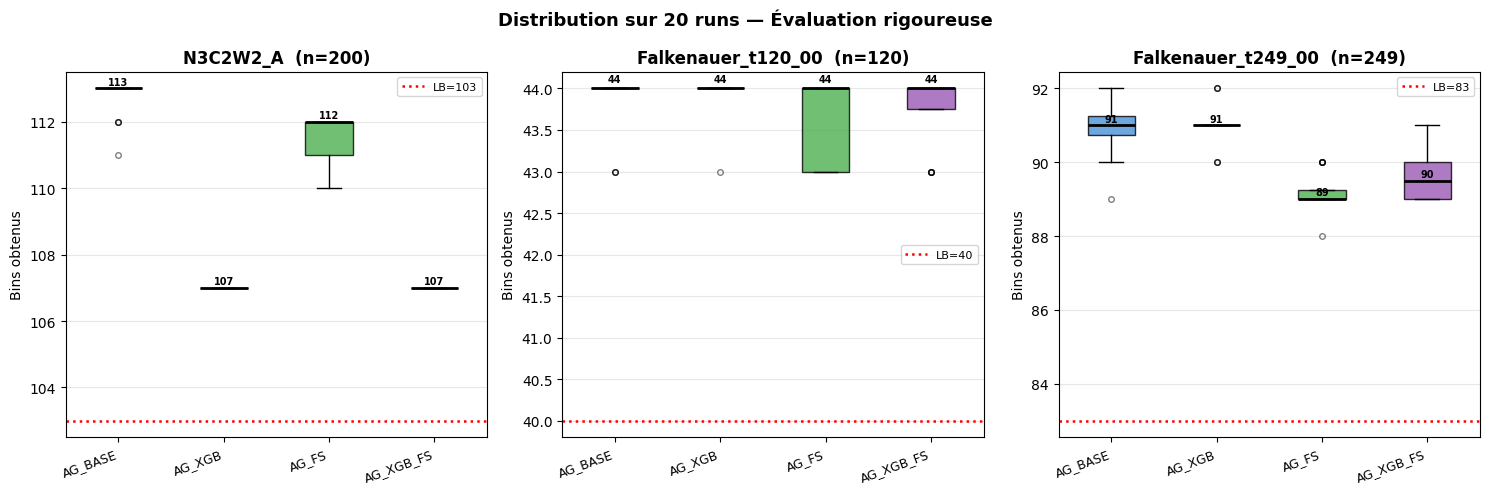

EVAL_G1 sauvegardé


In [ ]:
# ── G_EVAL_1 : Boxplots 20 runs par algo et par instance ──────────────
n_eval = len(eval_instances)
fig, axes = plt.subplots(1, n_eval, figsize=(5 * n_eval, 5), squeeze=False)

for idx, inst in enumerate(eval_instances):
    ax = axes[0][idx]; lb = lower_bound(inst)
    data = [[r.best_num_bins for r in eval_results[inst.name][label]]
            for label, _ in EVAL_ALGOS]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))
    for patch, color in zip(bp['boxes'], ALGO_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    ax.axhline(lb, color='red', linestyle=':', linewidth=1.8, label=f'LB={lb}')
    ax.set_xticks(range(1, len(EVAL_ALGOS) + 1))
    ax.set_xticklabels(ALGO_LABELS, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('Bins obtenus'); ax.set_title(f'{inst.name}  (n={inst.n})', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

    # Annotation des médianes
    for k, median_line in enumerate(bp['medians']):
        med_val = median_line.get_ydata()[0]
        ax.text(k + 1, med_val + 0.05, f'{med_val:.0f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

fig.suptitle(f'Distribution sur {EVAL_N_RUNS} runs — Évaluation rigoureuse',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('eval_g1_boxplots.png', dpi=130, bbox_inches='tight')
plt.show()
print("EVAL_G1 sauvegardé")


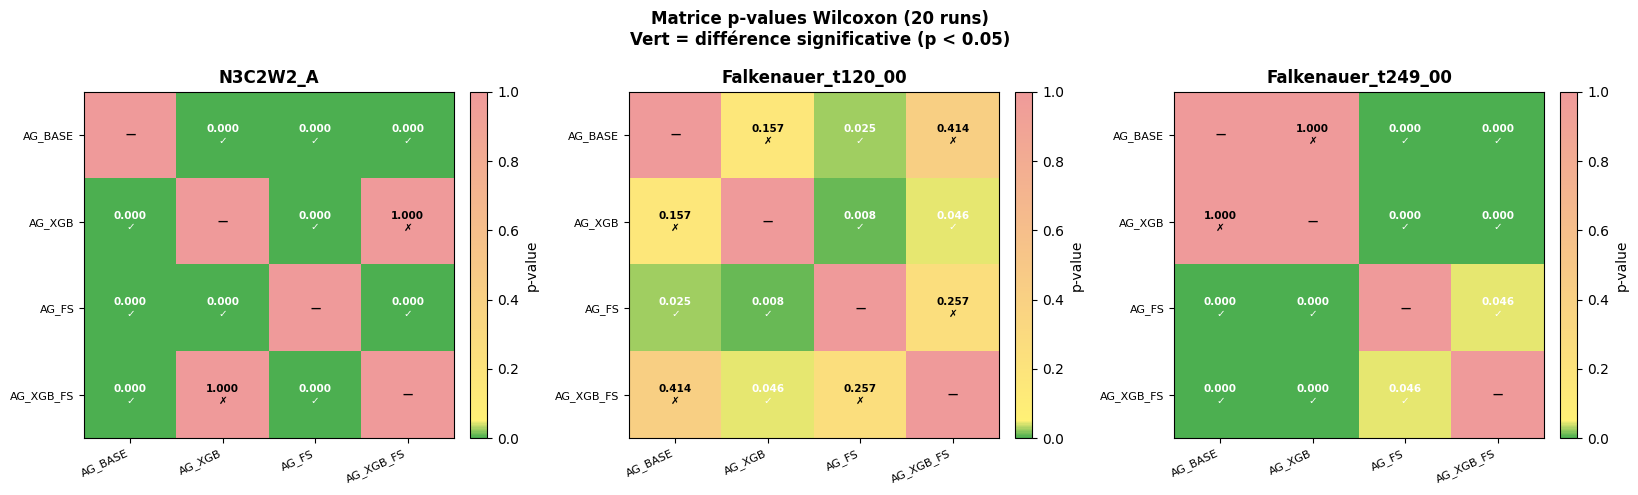

EVAL_G2 sauvegardé


In [ ]:
# ── G_EVAL_2 : Matrice de p-values Wilcoxon (heatmap) ────────────────
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, n_eval, figsize=(5.5 * n_eval, 5), squeeze=False)

for idx, inst in enumerate(eval_instances):
    ax = axes[0][idx]
    n_algos = len(EVAL_ALGOS)
    pval_matrix = np.ones((n_algos, n_algos))
    annot_matrix = [["" for _ in range(n_algos)] for _ in range(n_algos)]

    for i, (a1, _) in enumerate(EVAL_ALGOS):
        for j, (a2, _) in enumerate(EVAL_ALGOS):
            if i == j:
                pval_matrix[i][j] = 1.0
                annot_matrix[i][j] = "—"
                continue
            key = (inst.name, a1, a2) if (inst.name, a1, a2) in wilcoxon_results \
                  else (inst.name, a2, a1)
            if key in wilcoxon_results:
                pval = wilcoxon_results[key]['pval']
                pval_matrix[i][j] = pval
                sig = "✓" if pval < ALPHA_WILCOXON else "✗"
                annot_matrix[i][j] = f"{pval:.3f}\n{sig}"
            else:
                annot_matrix[i][j] = "N/A"

    cmap = mcolors.LinearSegmentedColormap.from_list(
        'pval', [(0, '#4CAF50'), (ALPHA_WILCOXON, '#FFF176'), (1, '#EF9A9A')])
    im = ax.imshow(pval_matrix, cmap=cmap, vmin=0, vmax=1, aspect='auto')

    ax.set_xticks(range(n_algos)); ax.set_xticklabels(ALGO_LABELS, rotation=25, ha='right', fontsize=8)
    ax.set_yticks(range(n_algos)); ax.set_yticklabels(ALGO_LABELS, fontsize=8)
    ax.set_title(f'{inst.name}', fontweight='bold')

    for i in range(n_algos):
        for j in range(n_algos):
            text_color = 'white' if pval_matrix[i][j] < 0.05 else 'black'
            ax.text(j, i, annot_matrix[i][j], ha='center', va='center',
                    fontsize=7.5, color=text_color, fontweight='bold')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='p-value')

fig.suptitle(f'Matrice p-values Wilcoxon ({EVAL_N_RUNS} runs)\n'
             f'Vert = différence significative (p < {ALPHA_WILCOXON})',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('eval_g2_wilcoxon_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print("EVAL_G2 sauvegardé")


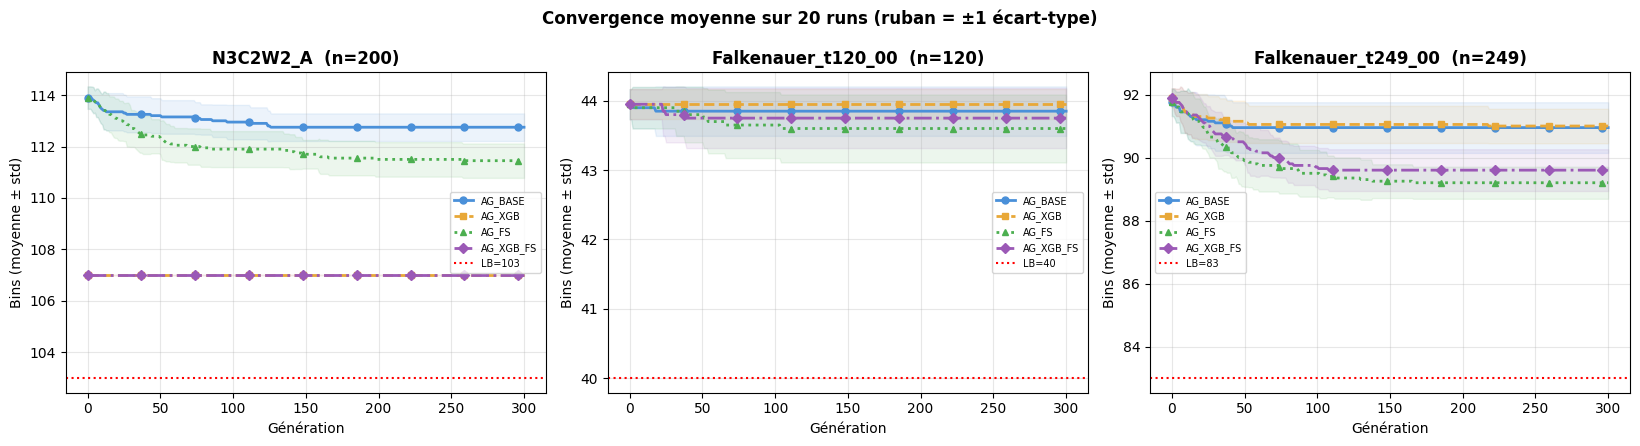

EVAL_G3 sauvegardé


In [ ]:
# ── G_EVAL_3 : Courbes de convergence — moyenne sur 20 runs ──────────
fig, axes = plt.subplots(1, n_eval, figsize=(5.5 * n_eval, 4.5), squeeze=False)

for idx, inst in enumerate(eval_instances):
    ax = axes[0][idx]; lb = lower_bound(inst)
    for k, (label, _) in enumerate(EVAL_ALGOS):
        # Aligner les courbes sur la longueur maximale, puis moyenner
        convs = [r.convergence for r in eval_results[inst.name][label]]
        max_len = max(len(c) for c in convs)
        padded = np.array([c + [c[-1]] * (max_len - len(c)) for c in convs])
        mean_conv = padded.mean(axis=0)
        std_conv  = padded.std(axis=0)

        ax.plot(mean_conv, color=ALGO_COLORS[k], linewidth=2,
                linestyle=['-','--',':','-.'][k], label=label,
                marker=ALGO_MARKERS[k], markevery=max(1, max_len // 8), markersize=5)
        ax.fill_between(range(max_len),
                        mean_conv - std_conv, mean_conv + std_conv,
                        color=ALGO_COLORS[k], alpha=0.10)

    ax.axhline(lb, color='red', linestyle=':', linewidth=1.5, label=f'LB={lb}')
    if inst.optimal:
        ax.axhline(inst.optimal, color='purple', linestyle='-.', linewidth=1,
                   label=f'Opt={inst.optimal}')
    ax.set_xlabel('Génération'); ax.set_ylabel('Bins (moyenne ± std)')
    ax.set_title(f'{inst.name}  (n={inst.n})', fontweight='bold')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

fig.suptitle(f'Convergence moyenne sur {EVAL_N_RUNS} runs (ruban = ±1 écart-type)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('eval_g3_convergence_moyenne.png', dpi=130, bbox_inches='tight')
plt.show()
print("EVAL_G3 sauvegardé")


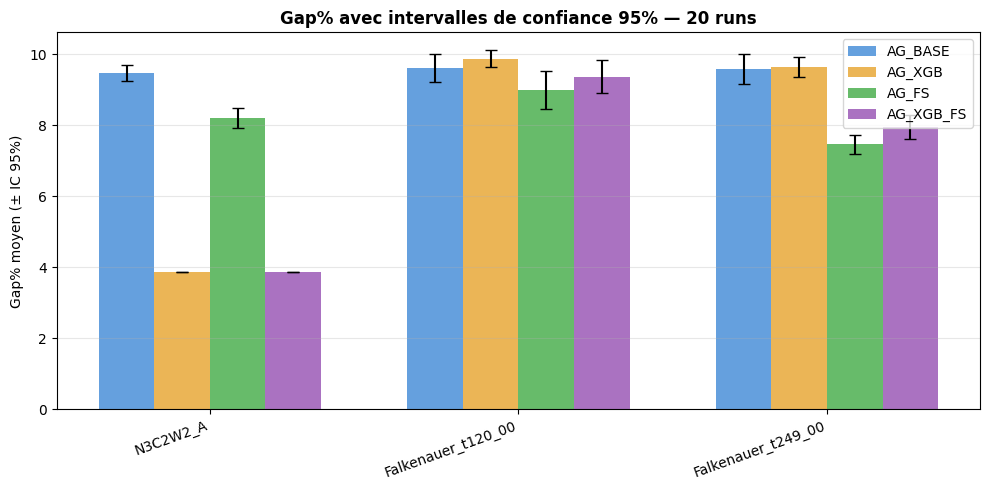

EVAL_G4 sauvegardé


In [ ]:
# ── G_EVAL_4 : Gap% moyen avec intervalles de confiance (95%) ─────────
fig, ax = plt.subplots(figsize=(10, 5))

eval_inst_names = [inst.name for inst in eval_instances]
x = np.arange(len(eval_inst_names)); w = 0.18
z95 = 1.96  # z-score 95%

for k, (label, _) in enumerate(EVAL_ALGOS):
    gaps_mean, gaps_ci = [], []
    for inst in eval_instances:
        lb = lower_bound(inst)
        bins = [r.best_num_bins for r in eval_results[inst.name][label]]
        mean_bins = np.mean(bins); std_bins = np.std(bins)
        gap = (mean_bins - lb) / lb * 100 if lb > 0 else 0
        ci  = z95 * std_bins / np.sqrt(len(bins)) / lb * 100 if lb > 0 else 0
        gaps_mean.append(gap); gaps_ci.append(ci)
    offset = (k - 1.5) * w
    ax.bar(x + offset, gaps_mean, w, label=label,
           color=ALGO_COLORS[k], alpha=0.85, yerr=gaps_ci,
           capsize=4, error_kw=dict(elinewidth=1.5, ecolor='black'))

ax.set_xticks(x); ax.set_xticklabels(eval_inst_names, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Gap% moyen (± IC 95%)')
ax.set_title(f'Gap% avec intervalles de confiance 95% — {EVAL_N_RUNS} runs',
             fontweight='bold')
ax.legend(loc='upper right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eval_g4_gap_CI.png', dpi=130, bbox_inches='tight')
plt.show()
print("EVAL_G4 sauvegardé")


### 9.7 Conclusion statistique

In [ ]:
print("=" * 70)
print("CONCLUSION STATISTIQUE — ÉVALUATION RIGOUREUSE")
print("=" * 70)
print(f"  Protocole : {EVAL_N_RUNS} runs × {len(eval_instances)} instances × {EVAL_MAX_GENS} gens max")
print(f"  Test      : Wilcoxon apparié bilatéral, alpha = {ALPHA_WILCOXON}")
print()

# Tableau global
eval_summary = df_eval.groupby("Algo")[["Mean", "Gap%"]].mean().round(3)
eval_summary.index = pd.CategoricalIndex(eval_summary.index, categories=ALGO_LABELS, ordered=True)
eval_summary = eval_summary.sort_index()

print(f"  {'Algorithme':<14} {'Gap% moy':>10} {'Bins moy':>10}")
print("  " + "-" * 36)
for algo in ALGO_LABELS:
    row = eval_summary.loc[algo]
    print(f"  {algo:<14} {row['Gap%']:>9.2f}% {row['Mean']:>10.2f}")

print()
print("  Résultats Wilcoxon (paires significatives) :")
found = False
for inst in eval_instances:
    for a1, a2 in pairs:
        key = (inst.name, a1, a2)
        if key not in wilcoxon_results: continue
        wr = wilcoxon_results[key]
        if wr['significant']:
            found = True
            print(f"    [{inst.name}] {a1} vs {a2} : p={wr['pval']:.4f} → {wr['winner']} significativement meilleur")

if not found:
    print("    Aucune différence statistiquement significative détectée.")
    print("    → Les algorithmes sont équivalents sur ces instances (avec ce budget).")

print()
best_eval = eval_summary["Gap%"].idxmin()
print(f"  ★ Meilleur algorithme global : {best_eval} (Gap% = {eval_summary.loc[best_eval,'Gap%']:.2f}%)")
print("=" * 70)


CONCLUSION STATISTIQUE — ÉVALUATION RIGOUREUSE
  Protocole : 20 runs × 3 instances × 300 gens max
  Test      : Wilcoxon apparié bilatéral, alpha = 0.05

  Algorithme       Gap% moy   Bins moy
  ------------------------------------
  AG_BASE             9.56%      82.52
  AG_XGB              7.80%      80.65
  AG_FS               8.22%      81.42
  AG_XGB_FS           7.07%      80.12

  Résultats Wilcoxon (paires significatives) :
    [N3C2W2_A] AG_BASE vs AG_XGB : p=0.0000 → AG_XGB significativement meilleur
    [N3C2W2_A] AG_BASE vs AG_FS : p=0.0001 → AG_FS significativement meilleur
    [N3C2W2_A] AG_BASE vs AG_XGB_FS : p=0.0000 → AG_XGB_FS significativement meilleur
    [N3C2W2_A] AG_XGB vs AG_FS : p=0.0001 → AG_XGB significativement meilleur
    [N3C2W2_A] AG_FS vs AG_XGB_FS : p=0.0001 → AG_XGB_FS significativement meilleur
    [Falkenauer_t120_00] AG_BASE vs AG_FS : p=0.0253 → AG_FS significativement meilleur
    [Falkenauer_t120_00] AG_XGB vs AG_FS : p=0.0082 → AG_FS significat

**Ce travail a été réalisé par:** *Berkat Cheraz Ichrek, Allouche Reda , Bouderbala Amira, Marmouze Nor El Houda, Chattah Salsabila, Saidi Selma .*